In [ ]:
pip install pyspark

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('ml-bank').getOrCreate()
df = spark.read.csv("/content/bank.csv", header = True, inferSchema = True)
df.printSchema()


root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- deposit: string (nullable = true)



In [3]:
df.show(5)

+---+----------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+-------+
|age|       job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|deposit|
+---+----------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+-------+
| 59|    admin.|married|secondary|     no|   2343|    yes|  no|unknown|  5|  may|    1042|       1|   -1|       0| unknown|    yes|
| 56|    admin.|married|secondary|     no|     45|     no|  no|unknown|  5|  may|    1467|       1|   -1|       0| unknown|    yes|
| 41|technician|married|secondary|     no|   1270|    yes|  no|unknown|  5|  may|    1389|       1|   -1|       0| unknown|    yes|
| 55|  services|married|secondary|     no|   2476|    yes|  no|unknown|  5|  may|     579|       1|   -1|       0| unknown|    yes|
| 54|    admin.|married| tertiary|     no|    184|     no|  no|unknown|  5| 

In [4]:
df.dtypes

[('age', 'int'),
 ('job', 'string'),
 ('marital', 'string'),
 ('education', 'string'),
 ('default', 'string'),
 ('balance', 'int'),
 ('housing', 'string'),
 ('loan', 'string'),
 ('contact', 'string'),
 ('day', 'int'),
 ('month', 'string'),
 ('duration', 'int'),
 ('campaign', 'int'),
 ('pdays', 'int'),
 ('previous', 'int'),
 ('poutcome', 'string'),
 ('deposit', 'string')]

In [5]:
numeric_features = [t[0] for t in df.dtypes if t[1] == 'int']
numeric_features

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [8]:
df.select(numeric_features).describe().toPandas()

,summary,age,balance,day,duration,campaign,pdays,previous
0,count,11162,11162,11162,11162,11162,11162,11162
1,mean,41.231947679627304,1528.5385235620856,15.658036194230425,371.99381831213043,2.508421429851281,51.33040673714388,0.8325568894463358
2,stddev,11.913369192215518,3225.413325946149,8.420739541006462,347.12838571630687,2.7220771816614824,108.75828197197717,2.292007218670508
3,min,18,-6847,1,2,1,-1,0
4,max,95,81204,31,3881,63,854,58


In [6]:
df.show(5)

+---+----------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+-------+
|age|       job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|deposit|
+---+----------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+-------+
| 59|    admin.|married|secondary|     no|   2343|    yes|  no|unknown|  5|  may|    1042|       1|   -1|       0| unknown|    yes|
| 56|    admin.|married|secondary|     no|     45|     no|  no|unknown|  5|  may|    1467|       1|   -1|       0| unknown|    yes|
| 41|technician|married|secondary|     no|   1270|    yes|  no|unknown|  5|  may|    1389|       1|   -1|       0| unknown|    yes|
| 55|  services|married|secondary|     no|   2476|    yes|  no|unknown|  5|  may|     579|       1|   -1|       0| unknown|    yes|
| 54|    admin.|married| tertiary|     no|    184|     no|  no|unknown|  5| 

In [7]:
df = df.select('age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit')
cols = df.columns
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- deposit: string (nullable = true)



In [8]:
cols

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'deposit']

In [ ]:

1,2,3--4
5,6,7--8
9,10,11--9

[1,2,3]--4
[5,6,7]--8
[9,10,11]--9


TypeError: unsupported operand type(s) for -: 'list' and 'int'

In [9]:
df.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'deposit']

In [10]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
categoricalColumns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
stages = []
for categoricalCol in categoricalColumns:
    stringIndexer = StringIndexer(inputCol = categoricalCol, outputCol = categoricalCol + 'Index')
    # Converts the categorical text columns into numeric indices
    encoder = OneHotEncoder(inputCols=[stringIndexer.getOutputCol()], outputCols=[categoricalCol + "classVec"])
    # Converts Indices into Binary Vectors
    stages += [stringIndexer, encoder]
label_stringIdx = StringIndexer(inputCol = 'deposit', outputCol = 'label')
stages += [label_stringIdx]
numericCols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
assemblerInputs = [c + "classVec" for c in categoricalColumns] + numericCols
assembler = VectorAssembler(inputCols=assemblerInputs, outputCol="features")
stages += [assembler]


# Automation of the Data Encoding and feature assembly for ML Training

In [11]:
stages

# This output shows the complete Spark ML preprocessing pipeline, where each categorical column is
# indexed and one-hot encoded, and all features are finally combined into a single features vector
# for model training.

[StringIndexer_92aefe2e036e,
 OneHotEncoder_df08b173581d,
 StringIndexer_94d83c6dd212,
 OneHotEncoder_2e80878ca3a0,
 StringIndexer_42693d028733,
 OneHotEncoder_b0d31ffd1651,
 StringIndexer_b27c6e42d336,
 OneHotEncoder_43856777b687,
 StringIndexer_a2a73cd825f0,
 OneHotEncoder_fff8e249fb5f,
 StringIndexer_ec44592391e3,
 OneHotEncoder_9223cae15054,
 StringIndexer_2d3bd1111769,
 OneHotEncoder_f4564a30cdd6,
 StringIndexer_3492ca253c35,
 OneHotEncoder_3e0b14467291,
 StringIndexer_fda1f7550733,
 VectorAssembler_c7dee3ccb6c8]

In [12]:
from pyspark.ml import Pipeline
pipeline = Pipeline(stages = stages)
pipelineModel = pipeline.fit(df)
df = pipelineModel.transform(df)


In [14]:
df.show(2)

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  1.0|(30,[3,11,13,16,1...|
|  1.0|(30,[3,11,13,16,1...|
+-----+--------------------+
only showing top 2 rows


In [16]:
selectedCols = ['label', 'features']
df = df.select(selectedCols)

In [ ]:
df.show(2)

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  1.0|(30,[3,11,13,16,1...|
|  1.0|(30,[3,11,13,16,1...|
+-----+--------------------+
only showing top 2 rows


In [18]:
df.toPandas().shape

(11162, 2)

In [17]:
train, test = df.randomSplit([0.7, 0.3], seed = 2018)
print("Training Dataset Count: " + str(train.count()))
print("Test Dataset Count: " + str(test.count()))

Training Dataset Count: 7855
Test Dataset Count: 3307


In [19]:
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(featuresCol = 'features', labelCol = 'label', maxIter=10)
lrModel = lr.fit(train)

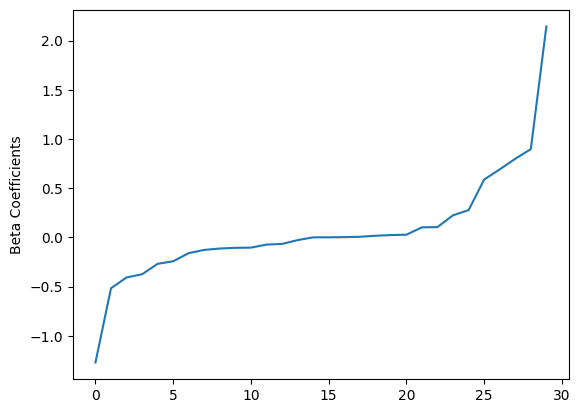

[np.float64(-1.2719397921299593), np.float64(-0.5182060016340925), np.float64(-0.40791142792509205), np.float64(-0.3754145237603563), np.float64(-0.2694280954585592), np.float64(-0.24326208160817983), np.float64(-0.16068620930481226), np.float64(-0.12787158571144386), np.float64(-0.11401635561256548), np.float64(-0.10678988572272315), np.float64(-0.10472851809728057), np.float64(-0.0741856028913645), np.float64(-0.06700017649026112), np.float64(-0.02850272272550807), np.float64(-0.0002805704378354507), np.float64(2.7885990522331954e-05), np.float64(0.00166543517370814), np.float64(0.005242762542846653), np.float64(0.016018087117837133), np.float64(0.02264928192178168), np.float64(0.02678088506799433), np.float64(0.1014834348580033), np.float64(0.10394646034591382), np.float64(0.224067138173959), np.float64(0.2762809837391419), np.float64(0.5872071811487516), np.float64(0.6901076731723863), np.float64(0.7978888820062994), np.float64(0.896239317306288), np.float64(2.1425803967744437)]


In [21]:
import matplotlib.pyplot as plt
import numpy as np
beta = np.sort(lrModel.coefficients)
plt.plot(beta)
plt.ylabel('Beta Coefficients')
plt.show()
print(list(beta))

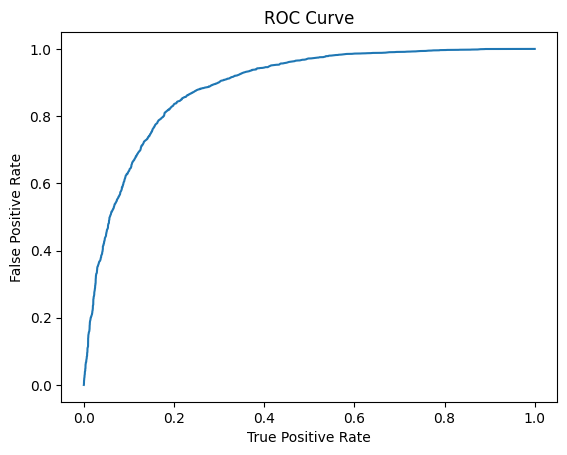

Training set areaUnderROC: 0.8877385690600346


In [22]:
trainingSummary = lrModel.summary
roc = trainingSummary.roc.toPandas()
plt.plot(roc['FPR'],roc['TPR'])
plt.ylabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()
print('Training set areaUnderROC: ' + str(trainingSummary.areaUnderROC))

In [23]:
predictions = lrModel.transform(test)
#predictions.select('age', 'job', 'label', 'rawPrediction', 'prediction', 'probability').show(10)

In [24]:
predictions.show()

+-----+--------------------+--------------------+--------------------+----------+
|label|            features|       rawPrediction|         probability|prediction|
+-----+--------------------+--------------------+--------------------+----------+
|  0.0|(30,[0,11,13,16,1...|[1.93084854518132...|[0.87334331124860...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[1.92783695472105...|[0.87300981013434...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[-0.7737627890180...|[0.31566570209269...|       1.0|
|  0.0|(30,[0,11,13,16,1...|[0.94708137344083...|[0.72052784002181...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2.44657764692467...|[0.92031082026377...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[1.28386077546041...|[0.78310624913887...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[1.05745870556541...|[0.74220460119093...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[3.25200815517471...|[0.96274520587479...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2.24978402804247...|[0.90463190417563...|       0.0|
|  0.0|(30,[0,11

In [25]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator()
print('Test Area Under ROC', evaluator.evaluate(predictions))

Test Area Under ROC 0.885643189559481


In [26]:
train.show()

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
|  0.0|(30,[0,11,13,16,1...|
+-----+--------------------+
only showing top 20 rows


In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier
dt = DecisionTreeClassifier(featuresCol = 'features', labelCol = 'label', maxDepth = 3)
dtModel = dt.fit(train)
predictions = dtModel.transform(test)
predictions.show(20,truncate = True)

+-----+--------------------+--------------+--------------------+----------+
|label|            features| rawPrediction|         probability|prediction|
+-----+--------------------+--------------+--------------------+----------+
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[520.0,1931.0]|[0.21215830273357...|       1.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[2498.0,481.0]|[0.83853642161799...|       0.0|
|  0.0|(30,[

In [28]:
evaluator = BinaryClassificationEvaluator()
print("Test Area Under ROC: " + str(evaluator.evaluate(predictions, {evaluator.metricName: "areaUnderROC"})))

Test Area Under ROC: 0.885643189559481


In [ ]:
from pyspark.ml.classification import RandomForestClassifier
rf = RandomForestClassifier(featuresCol = 'features', labelCol = 'label')
rfModel = rf.fit(train)
predictions = rfModel.transform(test)
predictions.show(10)

+-----+--------------------+--------------------+--------------------+----------+
|label|            features|       rawPrediction|         probability|prediction|
+-----+--------------------+--------------------+--------------------+----------+
|  0.0|(30,[0,11,13,16,1...|[15.4349062529981...|[0.77174531264990...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[15.0964158122948...|[0.75482079061474...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[7.09663042474726...|[0.35483152123736...|       1.0|
|  0.0|(30,[0,11,13,16,1...|[13.7307291859924...|[0.68653645929962...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[15.4245662016754...|[0.77122831008377...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[14.9958144487099...|[0.74979072243549...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[13.9242189952677...|[0.69621094976338...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[16.5838504357798...|[0.82919252178899...|       0.0|
|  0.0|(30,[0,11,13,16,1...|[16.1939892337409...|[0.80969946168704...|       0.0|
|  0.0|(30,[0,11

In [29]:
evaluator = BinaryClassificationEvaluator()
print("Test Area Under ROC: " + str(evaluator.evaluate(predictions, {evaluator.metricName: "areaUnderROC"})))

Test Area Under ROC: 0.885643189559481


In [31]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
evaluator = MulticlassClassificationEvaluator()